# Installations / import / création session spark

In [1]:
# Installation de modules
%pip install numpy matplotlib networkx pyspark tqdm PySide6 scipy nomkl ipykernel

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.4/563.4 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.6 MB/s eta 0:00:00
  Created wheel for nomkl: filename=nomkl-0.0.3-py3-none-any.whl size=987 sha256=6a8cb6c8e62520b55381abe7e5132adcc4425d03713833b139dc5b7d6cedd2d3
  Stored in directory: /root/.cache/pip/wheels/aa/7a/e7/ba216b063728c71411d8e9a4bc0323ee37a247f6d2e0461298
Successfully built nomkl


In [2]:
!git clone https://github.com/operiana/CCF-Algorithm-Implementation-with-PySpark.git

Cloning into 'CCF-Algorithm-Implementation-with-PySpark'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 13 (delta 3), reused 12 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 20.06 MiB | 25.46 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [6]:
# Pour décompresser l'archive .gz contenant le fichier texte
!gunzip /content/CCF-Algorithm-Implementation-with-PySpark/web-Google.txt.gz

In [8]:
# Import des modules
from pyspark import SparkConf
from pyspark.context import SparkContext
from pyspark import RDD

from typing import Iterable, Generator
from matplotlib.colors import CSS4_COLORS

import random
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import pyspark
import time
import os

%matplotlib inline

In [4]:
# Creation de session PySpark
sc = SparkContext.getOrCreate(SparkConf().setMaster("local[*]"))

# Rappel des algorithmes

Soit $G=(V,E)$ le graphe dont l'on cherche à extraire les composantes connexes.
L'algorithme $\texttt{CCF}$ peut-être décrit de la manière suivante :

1. $\texttt{INPUT}$ / Liste des arêtes du graphe $EL := \{(u, v)\}_{(u,v) \in E(G)}$ avec $u, v$ deux noeuds de $G$ représentés par leur identifiant, i.e. $u, v \in \llbracket 1, |V(G)| \rrbracket$.
2. $\texttt{RÉPÈTER JUSQU'À CONVERGENCE}$ / Critère de convergence : La collection de paires est inchangée avant et après l'application des deux phases MapReduce.
    1. $\texttt{CCF-Iterate}$ / Génération pour chaque noeud du noeud d'indice minimal qu'il peut atteindre en un saut. Les itérations successives permettent de considérer des chemins grandissant avec le numéro de l'itération.
    2. $\texttt{CCF-Dedup}$ / Déduplication des paires renvoyées après $\texttt{CCF-Iterate}$
3. $\texttt{OUTPUT}$ / Mapping $(u, C_{id}) \in V(G) \times C$, avec $C = \{C_i\}_i$ sa partition en composantes connexes.

In [5]:
class CCF:
        class GraphHandler:

                def __init__(self, G: nx.DiGraph, **kwargs):
                        self.G = G
                        self.V = G.nodes
                        self.E = G.edges
                        self.rdd_edges = sc.parallelize(self.E) # RDD qui contient les arêtes
                        self.cc_mapping = dict(zip(self.V, self.V)) # Dictionnaire qui mappe chaque noeud à sa composante connexe. Au début, chaque noeud appartient à sa propre composante connexe.
                        self.C = set(self.V) # Ensemble des composantes connexes
                        self.kwargs = kwargs

                def __str__(self):
                        return f"--{self.C=}\n"\
                                f"--{self.cc_mapping=}"

                def empty_ccmapping(self) -> None:
                        self.cc_mapping = dict(zip(self.V, self.V))
                        self.C = set(self.V)

                def create_ccmapping_from_rdd(self) -> None:
                        for node, component in self.rdd_edges.collect():
                                self.cc_mapping[node] = component
                                self.C = self.C - {node}

                def show_ccmapping(self, ax: plt.Axes = None):
                        id_to_component = dict(enumerate(self.C, start=1))
                        component_to_id = {v: k for k, v in id_to_component.items()}

                        if len(self.C) > len(sorted(CSS4_COLORS)):
                                print("Too many connected components but not enough colors.")
                        else:
                                color_picking = dict(enumerate(random.sample(sorted(CSS4_COLORS), len(self.C)), start=1))
                                cmap = [color_picking[component_to_id[self.cc_mapping[node]]] for node in self.V]
                                self.kwargs["node_color"] = cmap

                        labels = [component_to_id[self.cc_mapping[node]] for node in self.V]
                        nx.draw(self.G, labels = dict(zip(self.V, labels)), **self.kwargs)
                        plt.show()



        class Iterate:
                NEW_PAIR_COUNTER = sc.accumulator(0) # Counter that adress the problem of shared variable acces by workers

                @classmethod
                def map(cls, edge):
                        u, v = edge
                        yield (u, v)
                        yield (v, u)

                @classmethod
                def reduce(cls, input):
                        key, values = input

                        # Obliged to store the content of values in order to perform two passes : one to find the min id in values, the other one to emit pairs if necessary
                        buffer = []

                        # The min_id is key by default
                        min_id = key

                        # First pass : Finding the min id
                        for value in values:
                                if value < min_id:
                                        min_id = value
                                buffer.append(value)

                        # Second pass (if key is not minimal)
                        if min_id < key:
                                yield (key, min_id)

                                for value in buffer:
                                        if min_id != value:
                                                cls.NEW_PAIR_COUNTER.add(1)
                                                yield (value, min_id)

        class IterateWithSecondarySorting:
                NEW_PAIR_COUNTER = sc.accumulator(0)

                @classmethod
                def map(cls, edge):
                        u, v = edge
                        yield (u, v)
                        yield (v, u)

                @classmethod
                def reduce(cls, input):
                        key, values = input

                        # Solution : Trier la liste des voisins
                        sorted_values = sorted(list(values))

                        if not sorted_values:
                                return

                        # Le premier élément est le minimum grâce au tri
                        min_value = sorted_values[0]

                        # Si le nœud n'est pas minimal
                        if min_value < key:
                                yield (key, min_value)

                                # Une seule passe sur les voisins
                                for value in sorted_values[1:]:
                                        if value != min_value:
                                                cls.NEW_PAIR_COUNTER.add(1)
                                                yield (value, min_value)



        class Dedup:

                @classmethod
                def map(cls, edge):
                        return ((edge), None)

                @classmethod
                def reduce(cls, value1, value2):
                        return value1

                @classmethod
                def renormalize(cls, record):
                        edge, _ = record
                        return edge


        # Pipeline SANS secondary sorting (version originale)
        EXECUTION_PLAN_WithoutSS = lambda rdd : rdd\
                .flatMap(CCF.Iterate.map)\
                .groupByKey()\
                .flatMap(CCF.Iterate.reduce)\
                .map(CCF.Dedup.map)\
                .reduceByKey(CCF.Dedup.reduce)\
                .map(CCF.Dedup.renormalize)

        # Pipeline AVEC secondary sorting (version optimisée)
        EXECUTION_PLAN_WithSS = lambda rdd: rdd\
                .flatMap(CCF.IterateWithSecondarySorting.map)\
                .groupByKey()\
                .flatMap(CCF.IterateWithSecondarySorting.reduce)\
                .distinct()\
                .cache()

        @classmethod
        def forward_pass(cls, graph_handler: GraphHandler, WithSecondarySort: bool = False) -> tuple[bool, int]:
                """RDD --> Iterate --> Dedup --> NewPairVerification """

                # Sélection du pipeline en fonction du paramètre
                if WithSecondarySort:
                        graph_handler.rdd_edges = cls.EXECUTION_PLAN_WithSS(graph_handler.rdd_edges)
                else:
                        graph_handler.rdd_edges = cls.EXECUTION_PLAN_WithoutSS(graph_handler.rdd_edges)

                #print(f"--{graph_handler.rdd_edges.collect()=}") # ATTENTION A CE COLLECT() QUI RISQUE DE FAIRE UN OUT OF MEMORY SUR LES GROS GRAPHES

                num_of_pairs = graph_handler.rdd_edges.count() # Mandatory to perform an action in order to apply effectively the forward pass

                # Sélection du compteur approprié
                if WithSecondarySort:
                        has_new_pair = cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value > 0
                else:
                        has_new_pair = cls.Iterate.NEW_PAIR_COUNTER.value > 0

                return has_new_pair, num_of_pairs


        @classmethod
        def apply_CCF(cls, G: nx.DiGraph, WithSecondarySort: bool = False, **kwargs) -> GraphHandler:
                """
                Algorithme principal

                Args:
                    G: Graphe NetworkX
                    WithSecondarySort: Si True, utilise la version avec secondary sorting (optimisée)
                                      Si False, utilise la version classique
                    **kwargs: Arguments pour la visualisation
                """

                graph_handler = cls.GraphHandler(G, **kwargs)

                has_new_pair = True
                iter = 0

                # Affichage du mode utilisé
                mode = "WITH Secondary Sorting" if WithSecondarySort else "WITHOUT Secondary Sorting"
                print(f"\n{'='*60}")
                print(f"Starting CCF algorithm {mode}")
                print(f"{'='*60}\n")

                # Tant que de nouvelles paires sont générées, on répète le processus
                while has_new_pair:
                        print(f"{'ITERATION '+str(iter):-^50}")

                        has_new_pair, num_of_pairs = cls.forward_pass(graph_handler, WithSecondarySort)

                        # Affichage avec le bon compteur
                        if WithSecondarySort:
                                counter_value = cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value
                                print(f"--{num_of_pairs=}")
                                print(f"--NEW_PAIR_COUNTER={counter_value}")
                                print(f"--{has_new_pair=}")
                        else:
                                counter_value = cls.Iterate.NEW_PAIR_COUNTER.value
                                print(f"--{num_of_pairs=}")
                                print(f"--NEW_PAIR_COUNTER={counter_value}")
                                print(f"--{has_new_pair=}")

                        print(50*"-")

                        # Reset du bon compteur
                        if WithSecondarySort:
                                cls.IterateWithSecondarySorting.NEW_PAIR_COUNTER.value = 0
                        else:
                                cls.Iterate.NEW_PAIR_COUNTER.value = 0

                        iter += 1

                print(f"\nConvergence after {iter} iterations\n")

                graph_handler.create_ccmapping_from_rdd()
                #graph_handler.show_ccmapping()

                # When it has ended, show the mapping by collecting the RDD
                # print(graph_handler)
                # return graph_handler

# Tests on dummies graphs

In [ ]:
G = nx.DiGraph([(1,2), (2,3), (2,4), (4,5), (6,7), (7,8)])
G.edges

ghandler = CCF.GraphHandler(G)
CCF.apply_CCF(G)

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(7, 6), (4, 2), (8, 7), (2, 1), (8, 6), (3, 2), (5, 4), (3, 1), (4, 1), (5, 2)]
--num_of_pairs=10
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=4, value=4>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--graph_handler.edge_list.collect()=[(7, 6), (5, 1), (4, 2), (2, 1), (8, 6), (3, 1), (4, 1), (5, 2)]
--num_of_pairs=8
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=4, value=9>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--graph_handler.edge_list.collect()=[(7, 6), (5, 1), (2, 1), (8, 6), (3, 1), (4, 1)]
--num_of_pairs=6
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=4, value=4>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 3--------------------
--graph_handler.edge_list.collect()=[(7, 6), (5, 1), (

In [ ]:
G = nx.balanced_tree(2, 3)

fig, axs = plt.subplots(2, 1, figsize=(5,10))
nx.draw(G, ax=axs[0])

CCF.apply_CCF(G, ax = axs[1])

<IPython.core.display.Javascript object>

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(4, 0), (12, 2), (14, 2), (8, 1), (8, 3), (14, 6), (6, 2), (1, 0), (10, 1), (9, 4), (10, 4), (6, 0), (7, 1), (9, 1), (12, 5), (13, 6), (11, 2), (7, 3), (3, 0), (13, 2), (11, 5), (2, 0), (3, 1), (5, 0), (4, 1), (5, 2)]
--num_of_pairs=26
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=12>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--graph_handler.edge_list.collect()=[(4, 0), (12, 2), (14, 2), (9, 0), (8, 1), (8, 0), (14, 0), (6, 2), (10, 1), (1, 0), (7, 0), (6, 0), (7, 1), (9, 1), (11, 2), (11, 0), (10, 0), (3, 0), (13, 0), (13, 2), (2, 0), (12, 0), (3, 1), (4, 1), (5, 2), (5, 0)]
--num_of_pairs=26
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=32>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--graph_handler.edge_list.collect()=[(4, 

In [ ]:
G = nx.erdos_renyi_graph(20, 1/10, seed=10) # Erdős-Rényi graph with 20 vertices and 1/5 edge probability

fig, axs = plt.subplots(2, 1, figsize=(5,10))
nx.draw(G, ax=axs[0], node_size=200)

CCF.apply_CCF(G, ax = axs[1], node_size=200)

<IPython.core.display.Javascript object>

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(5, 3), (6, 1), (9, 2), (5, 1), (15, 1), (10, 6), (16, 4), (14, 0), (4, 2), (6, 2), (10, 1), (10, 3), (13, 10), (12, 8), (19, 6), (13, 4), (15, 10), (11, 1), (6, 4), (12, 1), (3, 2), (16, 13), (19, 8), (12, 6), (5, 2), (15, 4)]
--num_of_pairs=26
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=15>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--graph_handler.edge_list.collect()=[(13, 1), (6, 1), (8, 1), (15, 2), (9, 2), (15, 1), (16, 4), (4, 2), (16, 2), (6, 2), (14, 0), (5, 1), (10, 1), (10, 2), (10, 4), (19, 1), (13, 4), (2, 1), (19, 6), (11, 1), (8, 6), (12, 1), (3, 2), (13, 2), (3, 1), (5, 2), (4, 1)]
--num_of_pairs=27
--CCF.Iterate.NEW_PAIR_COUNTER=Accumulator<id=1, value=25>
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--graph_handler.ed

In [ ]:


G = nx.erdos_renyi_graph(2000, 1/250, seed=10) # Erdős-Rényi graph with 20 vertices and 1/5 edge probability

fig, axs = plt.subplots(2, 1, figsize=(5,10))
nx.draw(G, ax=axs[0], node_size=200)

CCF.apply_CCF(G, ax = axs[1], node_size=200)

-------------------ITERATION 0--------------------
--graph_handler.edge_list.collect()=[(480, 6), (522, 10), (929, 11), (1997, 11), (301, 11), (1490, 14), (650, 18), (344, 28), (1061, 31), (743, 33), (1641, 33), (751, 35), (183, 35), (921, 35), (995, 35), (416, 36), (880, 36), (1220, 42), (1298, 42), (1985, 43), (316, 44), (1476, 44), (820, 44), (334, 44), (460, 46), (1130, 46), (94, 46), (219, 49), (362, 50), (374, 50), (164, 52), (548, 52), (1120, 52), (658, 56), (1743, 57), (1759, 57), (1777, 57), (770, 60), (1131, 61), (990, 62), (1994, 62), (1875, 63), (810, 66), (268, 70), (1666, 70), (1040, 70), (1584, 70), (1236, 76), (237, 77), (551, 77), (458, 80), (1168, 80), (1350, 80), (854, 80), (160, 82), (656, 82), (778, 82), (1537, 83), (1083, 83), (970, 84), (847, 93), (1651, 95), (173, 95), (1358, 96), (277, 97), (401, 97), (385, 101), (306, 102), (490, 102), (989, 103), (850, 106), (1780, 110), (1964, 110), (1090, 112), (237, 115), (133, 117), (1190, 124), (1220, 124), (726, 136), (

#Tests on the paper dataset


🚀 ÉTAPE 1 : Test avec 100 arêtes
📊 Graphe chargé : 74 nœuds | 100 arêtes

⏳ Lancement SANS Secondary Sort...

Starting CCF algorithm WITHOUT Secondary Sorting

-------------------ITERATION 0--------------------
--num_of_pairs=104
--NEW_PAIR_COUNTER=101
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 1--------------------
--num_of_pairs=72
--NEW_PAIR_COUNTER=64
--has_new_pair=True
--------------------------------------------------
-------------------ITERATION 2--------------------
--num_of_pairs=72
--NEW_PAIR_COUNTER=0
--has_new_pair=False
--------------------------------------------------

Convergence after 3 iterations



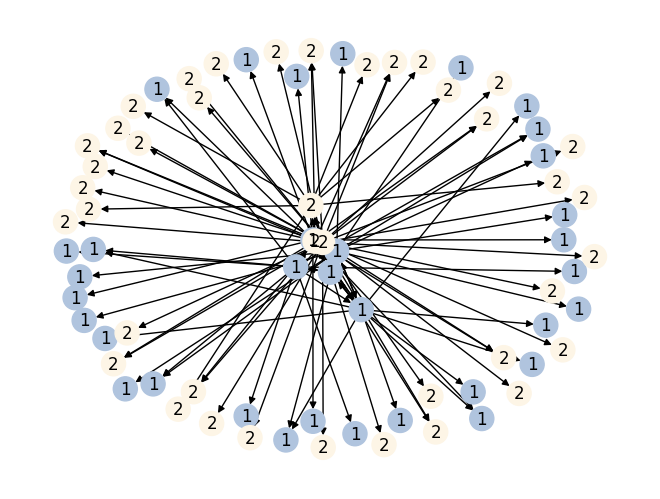

--self.C={0, 1}
--self.cc_mapping={0: 0, 11342: 0, 824020: 0, 867923: 0, 891835: 0, 27469: 0, 38716: 0, 309564: 0, 322178: 0, 387543: 0, 427436: 0, 538214: 0, 638706: 0, 645018: 0, 835220: 0, 856657: 0, 91807: 0, 417728: 0, 438493: 0, 500627: 0, 535748: 0, 695578: 0, 136593: 0, 414038: 0, 523684: 0, 760842: 0, 815602: 0, 846213: 0, 857527: 0, 112028: 0, 235849: 0, 302284: 0, 451592: 0, 693969: 0, 1: 1, 53051: 1, 203402: 1, 223236: 1, 276233: 1, 552600: 1, 569212: 1, 635575: 1, 748615: 1, 862566: 1, 893884: 1, 164684: 1, 184896: 1, 184984: 1, 240041: 1, 284930: 1, 303045: 1, 384341: 1, 408707: 1, 436135: 1, 449352: 1, 532018: 1, 539143: 1, 573555: 1, 604413: 1, 648208: 1, 773119: 1, 789543: 1, 792151: 1, 824625: 1, 838771: 1, 8517: 1, 14456: 1, 51573: 1, 150176: 1, 187770: 1, 189348: 1, 202191: 1, 225530: 1, 334309: 1}
✅ Terminé en 11.90s | Delta RAM: -4008.66 Mo

⏳ Lancement AVEC Secondary Sort...

Starting CCF algorithm WITH Secondary Sorting

-------------------ITERATION 0-----------

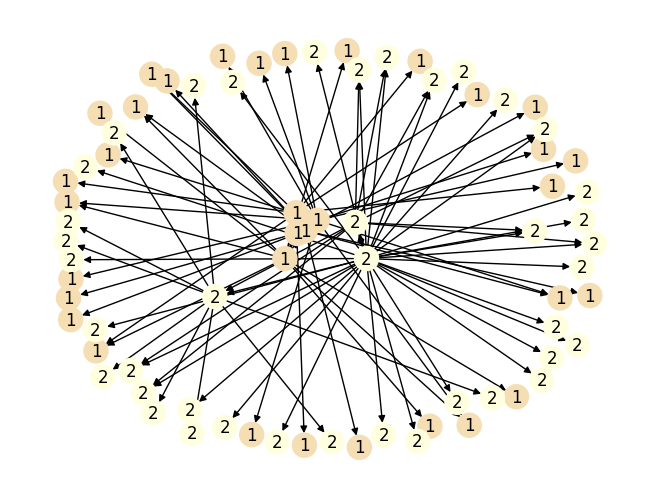

--self.C={0, 1}
--self.cc_mapping={0: 0, 11342: 0, 824020: 0, 867923: 0, 891835: 0, 27469: 0, 38716: 0, 309564: 0, 322178: 0, 387543: 0, 427436: 0, 538214: 0, 638706: 0, 645018: 0, 835220: 0, 856657: 0, 91807: 0, 417728: 0, 438493: 0, 500627: 0, 535748: 0, 695578: 0, 136593: 0, 414038: 0, 523684: 0, 760842: 0, 815602: 0, 846213: 0, 857527: 0, 112028: 0, 235849: 0, 302284: 0, 451592: 0, 693969: 0, 1: 1, 53051: 1, 203402: 1, 223236: 1, 276233: 1, 552600: 1, 569212: 1, 635575: 1, 748615: 1, 862566: 1, 893884: 1, 164684: 1, 184896: 1, 184984: 1, 240041: 1, 284930: 1, 303045: 1, 384341: 1, 408707: 1, 436135: 1, 449352: 1, 532018: 1, 539143: 1, 573555: 1, 604413: 1, 648208: 1, 773119: 1, 789543: 1, 792151: 1, 824625: 1, 838771: 1, 8517: 1, 14456: 1, 51573: 1, 150176: 1, 187770: 1, 189348: 1, 202191: 1, 225530: 1, 334309: 1}
✅ Terminé en 6.94s | Delta RAM: +53.26 Mo

🏆 BILAN ÉTAPE 1 :
   ⏱️ Temps : Le Secondary Sort est plus rapide de 4.96s (Speedup: 1.72x)
   💾 RAM   : Sans SS = -4008.66 Mo 

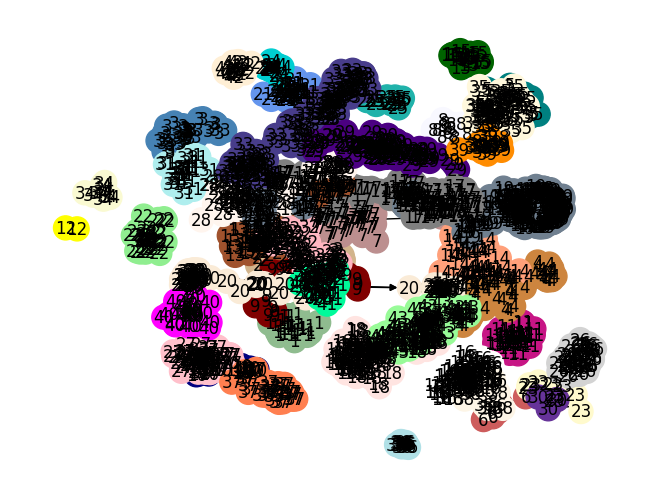

--self.C={0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 36, 37, 38, 40, 41, 42, 44, 47, 51, 54, 56, 57, 58}
--self.cc_mapping={0: 0, 11342: 0, 824020: 0, 867923: 0, 891835: 0, 27469: 0, 38716: 0, 309564: 0, 322178: 0, 387543: 0, 427436: 0, 538214: 0, 638706: 0, 645018: 0, 835220: 0, 856657: 0, 91807: 0, 417728: 0, 438493: 0, 500627: 0, 535748: 0, 695578: 0, 136593: 0, 414038: 0, 523684: 0, 760842: 0, 815602: 0, 846213: 0, 857527: 0, 112028: 0, 235849: 0, 302284: 0, 451592: 0, 693969: 0, 1: 1, 53051: 1, 203402: 1, 223236: 1, 276233: 1, 552600: 1, 569212: 1, 635575: 1, 748615: 1, 862566: 1, 893884: 1, 164684: 1, 184896: 1, 184984: 1, 240041: 1, 284930: 1, 303045: 1, 384341: 1, 408707: 1, 436135: 1, 449352: 1, 532018: 1, 539143: 1, 573555: 1, 604413: 1, 648208: 1, 773119: 1, 789543: 1, 792151: 1, 824625: 1, 838771: 1, 8517: 1, 14456: 1, 51573: 1, 150176: 1, 187770: 1, 189348: 1, 202191: 1, 225530: 1, 334309: 1, 421091: 1, 42

KeyboardInterrupt: 

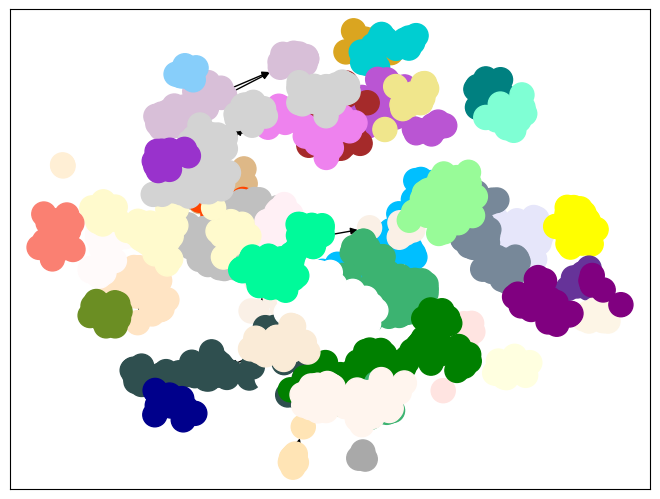

In [7]:
import networkx as nx
import time
import psutil
import gc

# 1. Outils de mesure
def get_ram_usage_mb():
    """Retourne la mémoire RAM globale utilisée par le système (Colab) en Mo.
       Cela permet de capter la RAM Python + la RAM de la JVM Spark."""
    return psutil.virtual_memory().used / (1024 * 1024)

def load_graph_sample(filepath: str, max_edges: int = None) -> nx.DiGraph:
    G = nx.DiGraph()
    edges_added = 0
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            if max_edges is not None and edges_added >= max_edges:
                break
            parts = line.strip().split('\t')
            if len(parts) == 2:
                u, v = int(parts[0]), int(parts[1])
                G.add_edge(u, v)
                edges_added += 1
    return G

# 2. Plan de test
stages = [
    (1, 100),
    (2, 5000),
    (3, 50000),
    (4, 250000),
    (5, None)       # Dataset complet
]

filepath = "/content/CCF-Algorithm-Implementation-with-PySpark/web-Google.txt"
results = [] # Pour stocker l'historique de nos métriques

# 3. Boucle d'exécution et de comparaison
for step, max_edges in stages:
    print(f"\n{'='*70}")
    print(f"🚀 ÉTAPE {step} : Test avec {max_edges if max_edges else 'TOUTES les'} arêtes")
    print(f"{'='*70}")

    # --- Chargement (commun aux deux tests) ---
    G = load_graph_sample(filepath, max_edges)
    print(f"📊 Graphe chargé : {G.number_of_nodes()} nœuds | {G.number_of_edges()} arêtes")

    # Variables pour stocker les métriques de cette étape
    metrics = {"step": step, "edges": G.number_of_edges()}

    for use_ss in [False, True]:
        mode_name = "AVEC Secondary Sort" if use_ss else "SANS Secondary Sort"
        print(f"\n⏳ Lancement {mode_name}...")

        # Forcer le ramasse-miettes avant le test pour une mesure RAM plus propre
        gc.collect()
        ram_before = get_ram_usage_mb()
        start_time = time.time()

        try:
            # Exécution de l'algorithme
            handler = CCF.apply_CCF(G, WithSecondarySort=use_ss)

            # Relevé des compteurs
            end_time = time.time()
            ram_after = get_ram_usage_mb()

            # Calcul des deltas
            duration = end_time - start_time
            ram_peak = ram_after - ram_before # Note: c'est une approximation du pic

            metrics[f"time_{use_ss}"] = duration
            metrics[f"ram_{use_ss}"] = ram_peak

            print(f"✅ Terminé en {duration:.2f}s | Delta RAM: {ram_peak:+.2f} Mo")

        except Exception as e:
            print(f"❌ ERREUR ({mode_name}) : {e}")
            metrics[f"time_{use_ss}"] = -1
            metrics[f"ram_{use_ss}"] = -1
            break # Si le "Sans SS" plante par manque de RAM, le "Avec SS" plantera surement aussi

    results.append(metrics)

    # Affichage du comparatif de l'étape
    if metrics.get("time_False", -1) != -1 and metrics.get("time_True", -1) != -1:
        time_diff = metrics["time_False"] - metrics["time_True"]
        speedup = metrics["time_False"] / metrics["time_True"] if metrics["time_True"] > 0 else 0

        print(f"\n🏆 BILAN ÉTAPE {step} :")
        print(f"   ⏱️ Temps : Le Secondary Sort est {'plus rapide' if time_diff > 0 else 'plus lent'} de {abs(time_diff):.2f}s (Speedup: {speedup:.2f}x)")
        print(f"   💾 RAM   : Sans SS = {metrics['ram_False']:+.2f} Mo | Avec SS = {metrics['ram_True']:+.2f} Mo")

In [ ]:
import matplotlib.pyplot as plt

def plot_benchmarks(results):
    # Extraction des données
    steps = [r['edges'] for r in results if r.get('time_True') != -1]
    time_no_ss = [r['time_False'] for r in results if r.get('time_True') != -1]
    time_with_ss = [r['time_True'] for r in results if r.get('time_True') != -1]

    ram_no_ss = [max(0, r['ram_False']) for r in results if r.get('time_True') != -1]
    ram_with_ss = [max(0, r['ram_True']) for r in results if r.get('time_True') != -1]

    plt.figure(figsize=(15, 6))

    # --- Graphique 1 : Temps d'exécution ---
    plt.subplot(1, 2, 1)
    plt.plot(steps, time_no_ss, 'o--', label='Sans Secondary Sort', color='red')
    plt.plot(steps, time_with_ss, 's-', label='Avec Secondary Sort', color='green')
    plt.xscale('log') # Échelle log car on passe de 100 à 5M
    plt.yscale('linear')
    plt.xlabel('Nombre d\'arêtes (échelle log)')
    plt.ylabel('Temps d\'exécution (secondes)')
    plt.title('Comparaison du temps d\'exécution')
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()

    # --- Graphique 2 : Utilisation RAM ---
    plt.subplot(1, 2, 2)
    plt.bar([f"St {r['step']}" for r in results], ram_no_ss, width=-0.4, align='edge', label='Sans SS', color='salmon')
    plt.bar([f"St {r['step']}" for r in results], ram_with_ss, width=0.4, align='edge', label='Avec SS', color='seagreen')
    plt.xlabel('Étapes de montée en charge')
    plt.ylabel('Delta RAM estimé (Mo)')
    plt.title('Comparaison de l\'empreinte mémoire')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Appeler la fonction à la fin de ton script
plot_benchmarks(results)